## Expérimentation de modèles

In [28]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import (
    Lasso, LassoCV,
    Ridge, LinearRegression
)
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCv
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score, get_scorer_names

ImportError: cannot import name 'GridSearchCv' from 'sklearn.model_selection' (/home/luckson/.virtualenvs/jupyter_env/lib/python3.12/site-packages/sklearn/model_selection/__init__.py)

In [6]:
train_data = pd.read_csv("../data/processed_dataset.csv")
test_data = pd.read_parquet("../data/test_data.parquet")

X_train = train_data.drop(
    ["LoyerMensuel_Log1", "LoyerMensuel_BIF", "IdentifiantMaison"],
    axis=1).select_dtypes(include=["number"])
y_train = train_data["LoyerMensuel_Log1"]

print(X_train)

     Chambres  Superficie_m2  DistanceRoute_m  AgeMaison  Salon_Bin  \
0         1.0           46.0            154.0       20.0          1   
1         4.0          217.0            211.0       23.0          1   
2         4.0          181.0             64.0       24.0          1   
3         6.0          253.0            255.0        2.0          1   
4         3.0          162.0             29.0       34.0          1   
..        ...            ...              ...        ...        ...   
377       4.0          183.0            213.0       14.0          1   
378       6.0          171.0            250.0       34.0          1   
379       5.0          223.0            293.0       16.0          1   
380       6.0          287.0             24.0       30.0          1   
381       6.0          272.0            235.0       31.0          1   

     SalleDeBainInterieure_Bin  Parking_Bin  Meuble_Bin  Jardin_Bin  \
0                            1            0           0           0   
1    

### Transformation de données de test

In [7]:
# Les variables numériques
feature_cols = ["AgeMaison", "Quartier_Target", "Indicateur_Confort", "Chambres_par_Superficie", "LoyerMensuel_Log1"]

for col in ['Salon', 'SalleDeBainInterieure', 'Parking', 'Meuble', 'Jardin']:
    test_data[col + "_Bin"] = test_data[col].map({"Oui": 1, "Non": 0}).fillna(0).astype(int)

neighbourhood_encoder = joblib.load("neighbourhood_encoder.joblib") 
test_data["Quartier_Target"] = neighbourhood_encoder.transform(test_data[["Quartier"]])[:, 0]

test_data["LoyerMensuel_Log1"] = np.log1p(test_data["LoyerMensuel_BIF"])

# Création de variables utiles pour le test
# cols_confort = ['Salon_Bin', 'SalleDeBainInterieure_Bin', 'Parking_Bin', 'Meuble_Bin', 'Jardin_Bin']
# test_data['Indicateur_Confort'] = test_data[cols_confort].sum(axis=1)

# test_data['Chambres_par_Superficie'] = test_data['Chambres'] / (test_data['Superficie_m2'] + 0.1)

# Séparation de X_test et y_test
X_test = test_data.drop(
    ["LoyerMensuel_Log1", "LoyerMensuel_BIF", "IdentifiantMaison"],
    axis=1).select_dtypes(include=["number"])
y_test = test_data["LoyerMensuel_Log1"]

X_test

,Chambres,Superficie_m2,DistanceRoute_m,AgeMaison,Salon_Bin,SalleDeBainInterieure_Bin,Parking_Bin,Meuble_Bin,Jardin_Bin,Quartier_Target
0,1.0,46.0,154.0,20.0,1,1,0,0,0,0.010428
1,4.0,217.0,211.0,23.0,1,1,0,0,0,0.002128
2,4.0,181.0,64.0,24.0,1,1,1,0,0,0.002182
3,6.0,253.0,255.0,2.0,1,1,0,0,1,0.001636
4,3.0,162.0,29.0,34.0,1,1,1,1,0,0.001636
...,...,...,...,...,...,...,...,...,...,...
377,4.0,183.0,213.0,14.0,1,1,0,0,1,0.002163
378,6.0,171.0,250.0,34.0,1,1,0,0,0,0.001636
379,5.0,223.0,293.0,16.0,1,1,0,0,1,0.002061
380,6.0,287.0,24.0,30.0,1,1,1,0,1,0.001636


In [8]:
def formated_time(second):
    m, s = divmod(second, 60)

    if m > 0:
         f"{int(m)} min {s:.4f} secondes"
    else:
        return f"{s:.4f} secondes"

scoring = ["neg_mean_squared_error", "neg_median_absolute_error", "neg_root_mean_squared_error", "r2"]

### Modèle de Régression Linéaire

In [9]:
linear_model = LinearRegression()

linear_scores = cross_validate(linear_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {linear_scores["fit_time"]}")
print()
print(f"Score Time : {linear_scores["score_time"]}")
print()
print(f"Test Neg Median Abosulte Error : {linear_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg Mean Squared Error : {linear_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test R2 : {linear_scores["test_r2"]}")

Fit Time : [0.21819997 0.00963902 0.00885177 0.0063026  0.00535393]

Score Time : [0.04850292 0.01742148 0.00868773 0.00649858 0.00559497]

Test Neg Median Abosulte Error : [-0.29193164 -0.33508889 -0.31824578 -0.24118789 -0.3432502 ]

Test Neg Mean Squared Error : [-0.28048846 -0.19495255 -0.19231695 -0.14773481 -0.16391579]

Test R2 : [0.38511628 0.60438951 0.39594465 0.5010853  0.51968459]


### Modèle Lasso

0.0003800267753306953


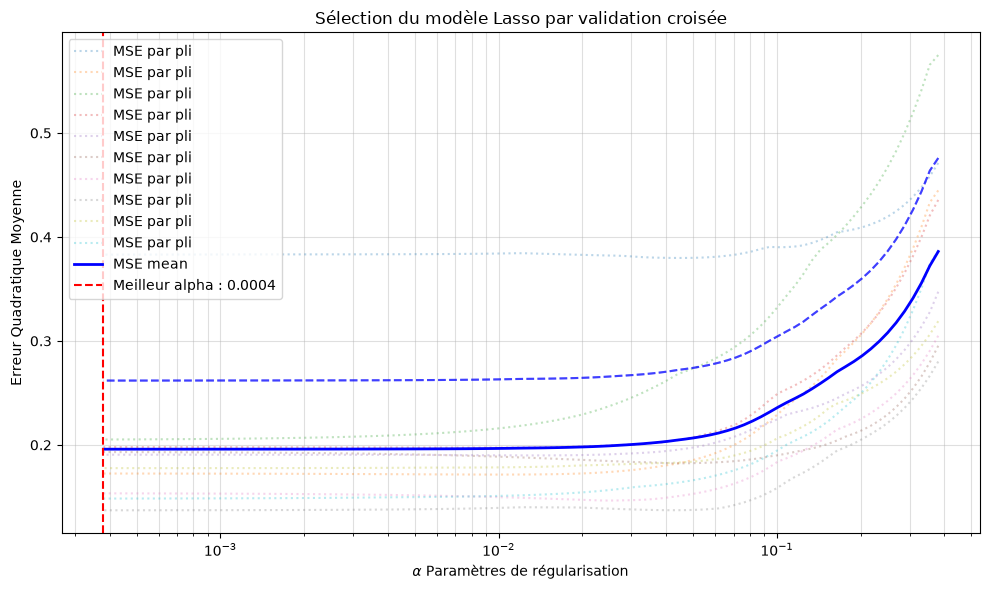

In [27]:
lasso_model = make_pipeline(StandardScaler(), LassoCV(cv=10, random_state=40))

lasso_model.fit(X_train, y_train)

lasso_cv = lasso_model[-1]

alphas = lasso_cv.alphas_
mse_mean = lasso_cv.mse_path_.mean(axis=1)
mse_std = lasso_cv.mse_path_.std(axis=1)
alpha_best = lasso_cv.alpha_

print(alpha_best)

plt.figure(figsize=(10, 6))

plt.semilogx(alphas, lasso_cv.mse_path_, ":", alpha=0.3, label="MSE par pli")
plt.semilogx(alphas, mse_mean, "b-", linewidth=2, label="MSE mean")

plt.semilogx(alphas, mse_mean + mse_std, "b--", alpha=0.5)
plt.semilogx(alphas, mse_mean + mse_std, "b--", alpha=0.5)

plt.axvline(alpha_best, color="r", linestyle="--", label=f"Meilleur alpha : {alpha_best:.4f}")

plt.xlabel(r"$\alpha$ Paramètres de régularisation")
plt.ylabel("Erreur Quadratique Moyenne")
plt.title("Sélection du modèle Lasso par validation croisée")
plt.legend()

plt.grid(True, which="both", ls="-", alpha=0.4)
plt.tight_layout()
plt.show()

### Ridget Model

In [7]:
ridge_model = Ridge(alpha=0.1)
ridge_scores = cross_validate(ridge_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {ridge_scores["fit_time"]}")
print()
print(f"Score Time : {ridge_scores["score_time"]}")
print()
print(f"Test Neg MSE : {ridge_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test Neg  MAE : {ridge_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg SMSE : {ridge_scores["test_neg_root_mean_squared_error"]}")
print()
print(f"Test R2 : {ridge_scores["test_r2"]}")

Fit Time : [0.00877166 0.00518823 0.00597978 0.00531745 0.01041317]

Score Time : [0.00680923 0.00590658 0.00561261 0.00861335 0.01581478]

Test Neg MSE : [-0.29862461 -0.2346449  -0.2073119  -0.18691915 -0.17880967]

Test Neg  MAE : [-0.31292038 -0.37353231 -0.35652329 -0.31659235 -0.35688442]

Test Neg SMSE : [-0.54646556 -0.48440159 -0.45531516 -0.43234148 -0.42285892]

Test R2 : [0.34535839 0.52384318 0.34884646 0.368756   0.4760417 ]


### Arbres de décision

In [8]:
tree_model = DecisionTreeRegressor()
tree_scores = cross_validate(tree_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {tree_scores["fit_time"]}")
print()
print(f"Score Time : {tree_scores["score_time"]}")
print()
print(f"Test Neg MSE : {tree_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test Neg  MAE : {tree_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg SMSE : {tree_scores["test_neg_root_mean_squared_error"]}")
print()
print(f"Test R2 : {tree_scores["test_r2"]}")

Fit Time : [0.00654244 0.00561833 0.00543165 0.00946999 0.01707911]

Score Time : [0.0055933  0.00736403 0.00608683 0.01534486 0.00811505]

Test Neg MSE : [-0.31832436 -0.2285527  -0.24208923 -0.22241931 -0.2258817 ]

Test Neg  MAE : [-0.28266242 -0.22750782 -0.33499307 -0.28258716 -0.28233327]

Test Neg SMSE : [-0.56420241 -0.47807186 -0.49202564 -0.47161352 -0.47527013]

Test R2 : [0.30217283 0.53620588 0.23961308 0.24886855 0.33810853]


### Modèle de Fôrets Aléatoire

In [9]:
random_model = RandomForestRegressor()

random_scores = cross_validate(random_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {random_scores["fit_time"]}")
print()
print(f"Score Time : {random_scores["score_time"]}")
print()
print(f"Test Neg MSE : {random_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test Neg  MAE : {random_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg SMSE : {random_scores["test_neg_root_mean_squared_error"]}")
print()
print(f"Test R2 : {random_scores["test_r2"]}")

Fit Time : [0.26407099 0.23846316 0.20796061 0.25242114 0.21350646]

Score Time : [0.01731014 0.01698542 0.01878572 0.02020049 0.01831269]

Test Neg MSE : [-0.20012232 -0.15704968 -0.10785947 -0.10506105 -0.1272582 ]

Test Neg  MAE : [-0.22514966 -0.26829397 -0.23951165 -0.22443281 -0.25446519]

Test Neg SMSE : [-0.44735033 -0.39629493 -0.32841965 -0.32413123 -0.35673268]

Test R2 : [0.56129405 0.68130451 0.66122025 0.64519869 0.62710074]


### Modèle de Gradient Boosting

In [10]:
boosting_model = GradientBoostingRegressor(random_state=0)

boosting_scores = cross_validate(boosting_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {boosting_scores["fit_time"]}")
print()
print(f"Score Time : {boosting_scores["score_time"]}")
print()
print(f"Test Neg MSE : {boosting_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test Neg  MAE : {boosting_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg SMSE : {boosting_scores["test_neg_root_mean_squared_error"]}")
print()
print(f"Test R2 : {boosting_scores["test_r2"]}")

Fit Time : [0.16113782 0.10639167 0.09976125 0.09202981 0.09305286]

Score Time : [0.00886965 0.00478458 0.00508952 0.00458908 0.00470591]

Test Neg MSE : [-0.18749778 -0.07400438 -0.05695738 -0.05778474 -0.06539959]

Test Neg  MAE : [-0.1438035  -0.16189354 -0.15416844 -0.17510174 -0.16474067]

Test Neg SMSE : [-0.43301013 -0.27203746 -0.23865746 -0.24038456 -0.25573343]

Test R2 : [0.58896943 0.84982547 0.82110047 0.80485537 0.8083624 ]
